In [2]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

df_fact_ticket = pd.read_csv(PROCESSED_DIR / "fact_ticket.csv")

df_fact_ticket["dob"] = pd.to_datetime(df_fact_ticket["dob"], errors="coerce")
df_fact_ticket["time"] = pd.to_datetime(df_fact_ticket["time"], errors="coerce")

In [15]:
df_fact_ticket.head()

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,no_error,"iPhone13,1",mobile
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,no_error,browser,website
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,Male,1989-05-18,no_campaign,Order successful,no_error,unknown,mobile
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,Male,1997-08-31,direct discount,Order successful,no_error,devicemodel,mobile
4,776efd7bda0b715084430e6385f67746,100965,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,Male,1988-09-20,direct discount,Order successful,no_error,devicemodel,mobile


In [3]:
df_time_analysis = df_fact_ticket[[
    "time",
    "final_price",
    "platform",
    "paying_method",
    "campaign_type",
    "movie_name"
]].copy()

In [8]:
df_time_analysis['hour'] = df_time_analysis['time'].dt.hour

In [18]:
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    else:
        return "Night"

df_time_analysis['time_of_day'] = df_time_analysis['hour'].apply(get_time_of_day)

In [17]:
df_time_analysis['hour'] = df_time_analysis['time'].dt.hour
df_time_analysis['day_of_week'] = df_time_analysis['time'].dt.day_name()
df_time_analysis['date'] = df_time_analysis['time'].dt.date
df_time_analysis['month'] = df_time_analysis['time'].dt.month

In [19]:
df_time_analysis.head()

,time,final_price,platform,paying_method,campaign_type,movie_name,hour,day_of_week,date,month,time_of_day
0,2022-07-08 17:46:36.145,7.80,mobile,money in app,direct discount,Thor: Love And Thunder,17,Friday,2022-07-08,7,Evening
1,2022-07-15 20:44:09.952,7.18,website,bank account,direct discount,Thor: Love And Thunder,20,Friday,2022-07-15,7,Evening
2,2022-07-30 11:16:55.483,8.00,mobile,money in app,no_campaign,Thor: Love And Thunder,11,Saturday,2022-07-30,7,Morning
3,2022-07-04 22:33:07.458,26.72,mobile,bank account,direct discount,Thor: Love And Thunder,22,Monday,2022-07-04,7,Night
4,2022-07-03 18:41:45.098,3.30,mobile,money in app,direct discount,Thor: Love And Thunder,18,Sunday,2022-07-03,7,Evening


<Axes: title={'center': 'Purchase Distribution by Hour'}, xlabel='hour'>

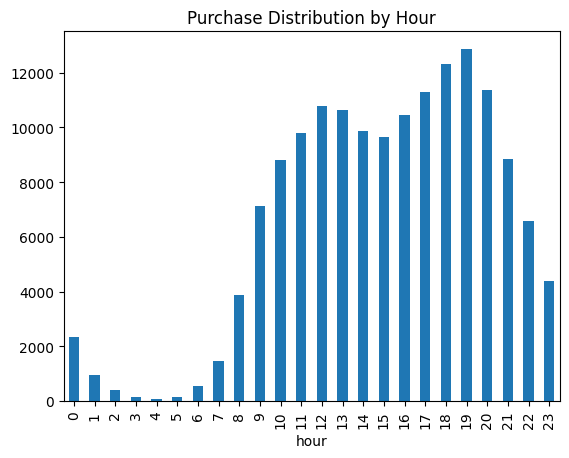

In [20]:
hourly = df_time_analysis['hour'].value_counts().sort_index()

hourly.plot(kind='bar', title='Purchase Distribution by Hour')

Purchase activity exhibits a strong temporal pattern, with a clear peak during evening hours, particularly between 19:00 and 20:00.

Transaction volume increases steadily throughout the day, starting from late morning and accelerating significantly in the afternoon, indicating a gradual buildup of user intent.

Early morning hours (00:00–06:00) show minimal activity, representing low-engagement periods.

This pattern suggests that ticket purchasing behavior is closely aligned with users' daily routines, with most transactions occurring during post-work leisure time.

Peak hours (17:00–21:00) should be prioritized for marketing and promotions.
Campaigns should be scheduled before peak time (15:00–17:00) to maximize conversion.
Off-peak hours (00:00–06:00) represent an opportunity for demand stimulation through targeted discounts.

<Axes: title={'center': 'Purchase by Time of Day'}, xlabel='time_of_day'>

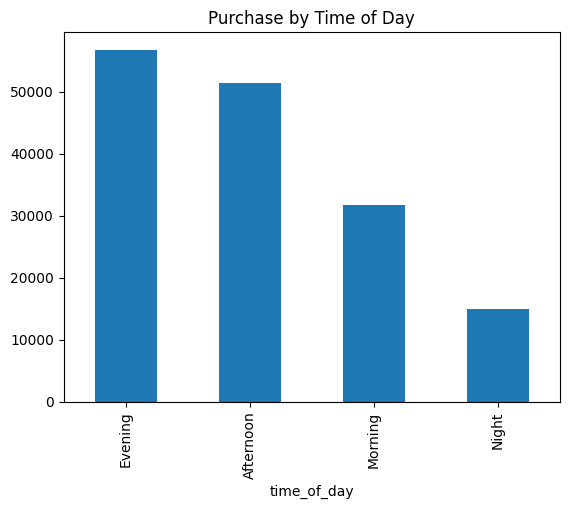

In [21]:
df_time_analysis['time_of_day'].value_counts().plot(kind='bar', title='Purchase by Time of Day')

<Axes: title={'center': 'Revenue by Hour'}, xlabel='hour'>

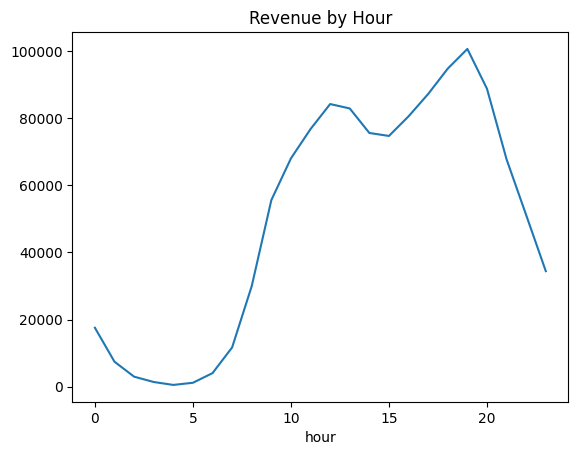

In [22]:
df_time_analysis.groupby('hour')['final_price'].sum().plot(title='Revenue by Hour')

Purchase behavior follows a two-phase pattern throughout the day. Activity begins to increase during the afternoon, suggesting a consideration phase where users explore options, and reaches its peak in the evening (18:00–21:00), indicating the primary conversion window.

The evening period not only dominates in transaction volume but also generates the highest revenue, highlighting it as the most valuable time segment for the business.

In contrast, night and early morning hours show significantly lower engagement, representing low-value time windows.

This pattern suggests that ticket purchasing behavior is strongly aligned with users’ daily routines, with most decisions made during post-work leisure time.

<Axes: title={'center': 'Purchase by Day'}, xlabel='day_of_week'>

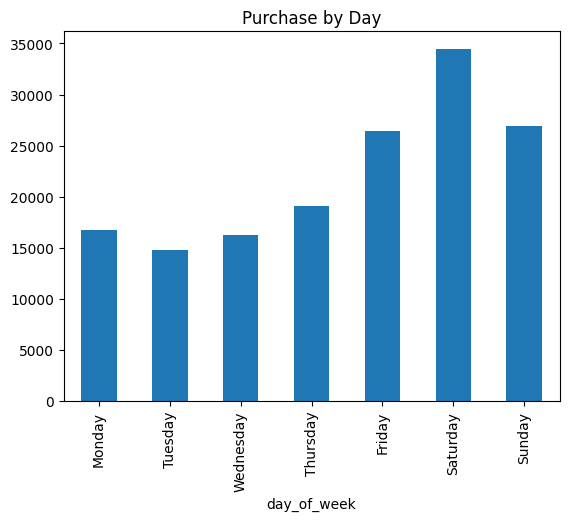

In [23]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

daily = df_time_analysis['day_of_week'].value_counts().reindex(order)

daily.plot(kind='bar', title='Purchase by Day')

<Axes: xlabel='hour', ylabel='day_of_week'>

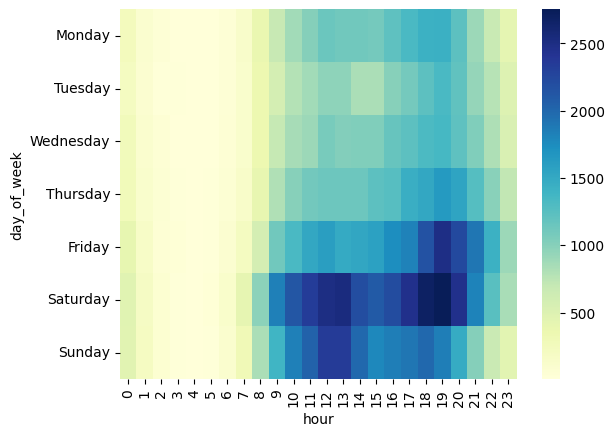

In [24]:
import seaborn as sns

heatmap_data = df_time_analysis.groupby(['day_of_week','hour']).size().unstack()
heatmap_data = heatmap_data.reindex(order)

sns.heatmap(heatmap_data, cmap='YlGnBu')

Purchase behavior follows a strong weekly and daily pattern, with demand gradually building from mid-week and peaking during the weekend.

Saturday emerges as the highest-performing day, with the most intense activity concentrated between 18:00 and 21:00, representing the absolute peak period across the entire dataset.

Friday marks the transition into peak demand, showing a significant increase in evening transactions as users begin their weekend activities.

In contrast, weekdays exhibit relatively lower and more stable purchasing patterns, with moderate activity primarily occurring during evening hours.

The heatmap further highlights that weekend demand is sustained throughout the day, particularly on Saturday, where high activity spans from late morning to late evening.

These patterns confirm that ticket purchasing behavior is heavily driven by leisure time availability, with users preferring to engage during weekends and evening hours.

Weekend (especially Saturday evening) should be the primary focus for premium pricing and high-value campaigns.
Marketing efforts should be intensified on Friday afternoon to capture users entering the weekend decision phase.
Weekday demand can be improved through targeted promotions, particularly during low-engagement periods.
Resource allocation (e.g., server capacity, customer support) should be optimized around peak periods to ensure performance stability.

🎯 PURCHASE TIMING ANALYSIS – FULL INSIGHTS
1. Overall Temporal Behavior

Purchase activity exhibits a clear and consistent temporal pattern throughout the day.
Transaction volume begins to increase from late morning, accelerates during the afternoon, and reaches its peak in the evening (18:00–21:00).

Early morning hours (00:00–06:00) show minimal activity, indicating low engagement during these periods.

👉 This suggests that user purchasing behavior is strongly aligned with daily routines, with most transactions occurring during post-work leisure time.

2. Time-of-Day Segmentation

Analysis by time segments reveals a two-phase behavioral pattern:

Afternoon represents a strong activity period, indicating a consideration phase where users explore options.
Evening dominates transaction volume, acting as the primary conversion window.

Morning activity is moderate, while night-time activity remains significantly lower.

👉 This indicates that users tend to browse during the day and complete purchases in the evening.

3. Revenue Patterns

Revenue trends closely follow transaction volume but highlight even stronger concentration during peak hours.

Peak revenue occurs around 19:00–20:00
Revenue increases steadily from late morning and surges in the evening

👉 This confirms that evening hours are not only high in volume but also the most valuable in terms of revenue generation.

4. Weekly Purchasing Behavior

A strong weekly pattern is observed:

Saturday is the highest-performing day
Friday and Sunday also show elevated activity
Weekdays (Monday–Thursday) exhibit lower and more stable transaction levels
Tuesday shows the lowest activity

👉 This reflects a typical entertainment consumption pattern where demand increases toward the weekend.

5. Combined Time & Day Behavior (Heatmap Insights)

The heatmap reveals deeper behavioral patterns:

Saturday evening (18:00–21:00) represents the absolute peak across the dataset
Friday evening marks the transition into peak demand
Weekend activity is sustained throughout the day, especially on Saturday
Weekday activity is mostly concentrated in the evening with lower intensity
Early morning hours remain consistently low across all days

👉 This confirms that both time of day and day of week jointly drive purchasing behavior.

6. Key Behavioral Patterns

From all analyses, several key patterns emerge:

Users exhibit a daily routine-driven purchasing pattern
There is a clear build-up phase (afternoon) followed by a conversion phase (evening)
Demand is significantly higher during weekends, especially Saturday
Peak performance occurs when weekend and evening overlap
💼 BUSINESS IMPLICATIONS
Marketing Timing Optimization
Schedule campaigns during 15:00–17:00 to capture users before peak conversion hours
Peak Hour Strategy
Focus premium pricing, upselling, and major promotions during 18:00–21:00
Weekend Optimization
Allocate more resources and campaigns toward Friday–Sunday, especially Saturday
Off-Peak Activation
Introduce targeted promotions during low-demand periods (early morning & weekdays)
Product & Platform Optimization
Ensure system performance and user experience are optimized during peak periods

<Axes: title={'center': 'Purchase Trend by Month'}, xlabel='year_month'>

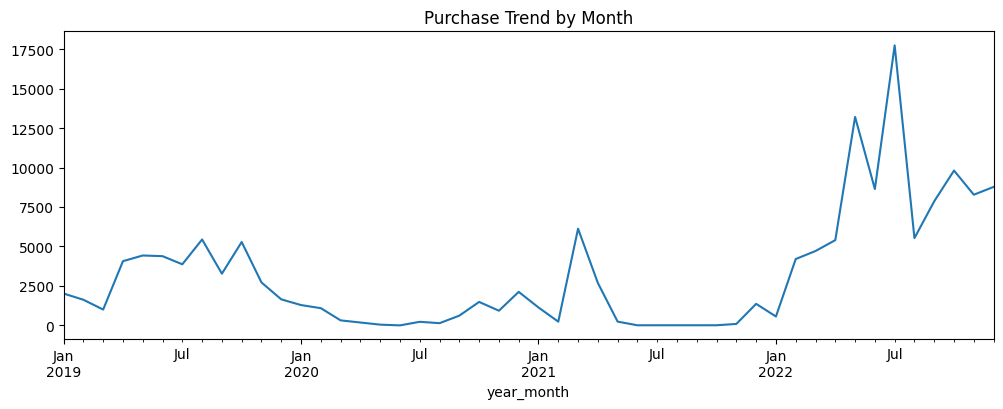

In [4]:
df_time_analysis['year_month'] = df_time_analysis['time'].dt.to_period('M')

monthly_trend = df_time_analysis.groupby('year_month').size()

monthly_trend.plot(figsize=(12,4), title='Purchase Trend by Month')

The purchase trend exhibits a clear long-term pattern with three distinct phases: stable activity in 2019, a sharp decline in 2020, and strong recovery followed by rapid growth in 2022.

The significant drop in 2020 suggests an external disruption, likely related to global events affecting entertainment consumption.

In contrast, 2022 demonstrates a strong rebound with multiple peaks, indicating increased user engagement and potential growth in the platform's adoption.

However, the presence of sharp fluctuations suggests that demand remains volatile and may be influenced by external factors such as movie releases or promotional campaigns.